# Optimizers and schedulers

## Data

### Imports

In [32]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy
from collections import defaultdict

### Data generation

In [33]:
def generate_regression_data(n_samples, noise=0.1):
    X = np.random.rand(n_samples, 1) * 10
    y = 2 * X + 1 + noise * np.random.randn(n_samples, 1)
    return X, y

### Generic model

In [34]:
class SimpleRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)

### Optimizers

### Nesterov

In [35]:
class NesterovOptimizer:
    def __init__(self, params, learning_rate=0.003, momentum_factor=0.9):
        self.params = list(params)
        self.learning_rate = learning_rate
        self.momentum_factor = momentum_factor
        self.velocity = {param: torch.zeros_like(param.data) for param in self.params}
    def step(self):
        for param in self.params:
            if param.grad is None:
                continue
            gradient = param.grad
            self.velocity[param] = self.momentum_factor * self.velocity[param] + self.learning_rate * gradient
            param.data -= self.momentum_factor * self.velocity[param] + self.learning_rate * gradient
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

### Adam

In [36]:
class AdamOptimizer:
    def __init__(self, params, learning_rate=0.003, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.params = list(params)
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.time_step = 0
        self.moment_1 = {param: torch.zeros_like(param.data) for param in self.params}
        self.moment_2 = {param: torch.zeros_like(param.data) for param in self.params}
    def step(self):
        self.time_step += 1
        for param in self.params:
            if param.grad is None:
                continue
            gradient = param.grad
            self.moment_1[param] = self.beta1 * self.moment_1[param] + (1 - self.beta1) * gradient
            self.moment_2[param] = self.beta2 * self.moment_2[param] + (1 - self.beta2) * gradient**2
            moment_1_corrected = self.moment_1[param] / (1 - self.beta1 ** self.time_step)
            moment_2_corrected = self.moment_2[param] / (1 - self.beta2 ** self.time_step)
            param.data -= self.learning_rate * moment_1_corrected / (torch.sqrt(moment_2_corrected) + self.epsilon)
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

### RMSProp

In [37]:
class RMSpropOptimizer:
    def __init__(self, params, learning_rate=0.003, decay_rate=0.99, epsilon=1e-4):
        self.params = list(params)
        self.learning_rate = learning_rate
        self.decay_rate = decay_rate
        self.epsilon = epsilon
        self.squared_avg_grad = {param: torch.zeros_like(param.data) for param in self.params}
    def step(self):
        for param in self.params:
            if param.grad is None:
                continue
            gradient = param.grad
            self.squared_avg_grad[param] = self.decay_rate * self.squared_avg_grad[param] + (1 - self.decay_rate) * gradient**2
            param.data -= self.learning_rate * gradient / (torch.sqrt(self.squared_avg_grad[param]) + self.epsilon)
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

## Schedulers

### StepLR

In [38]:
class StepLRScheduler:
    def __init__(self, optimizer, step_size, gamma_factor):
        self.optimizer = optimizer
        self.step_size = step_size
        self.gamma_factor = gamma_factor
        self.current_epoch = 0
    def step(self):
        self.current_epoch += 1
        if self.current_epoch % self.step_size == 0:
            self.optimizer.learning_rate *= self.gamma_factor

### ExponentialLR

In [39]:
class ExponentialLRScheduler:
    def __init__(self, optimizer, gamma_factor):
        self.optimizer = optimizer
        self.gamma_factor = gamma_factor
    def step(self):
        self.optimizer.learning_rate *= self.gamma_factor

## Training

In [40]:
def train_regression_model(optimizer_name, scheduler_name, scheduler_params, num_epochs=150, initial_learning_rate=0.003):
    X, Y = generate_regression_data(5000)
    x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    model = SimpleRegressionNN()
    loss_criterion = nn.HuberLoss()

    if optimizer_name == "Nesterov":
        optimizer = NesterovOptimizer(model.parameters(), learning_rate=initial_learning_rate)
    elif optimizer_name == "Adam":
        optimizer = AdamOptimizer(model.parameters(), learning_rate=initial_learning_rate)
    elif optimizer_name == "RMSprop":
        optimizer = RMSpropOptimizer(model.parameters(), learning_rate=initial_learning_rate)

    if scheduler_name == "StepLR":
        scheduler = StepLRScheduler(optimizer, **scheduler_params)
    elif scheduler_name == "ExponentialLR":
        scheduler = ExponentialLRScheduler(optimizer, **scheduler_params)

    learning_rates = []
    validation_losses = []

    for epoch in range(num_epochs):
        model.train()
        predictions = model(x_train_tensor)
        loss = loss_criterion(predictions, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(x_val_tensor)
            val_loss = loss_criterion(val_predictions, y_val_tensor)

        learning_rates.append(optimizer.learning_rate)
        validation_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f"[{optimizer_name} + {scheduler_name}] [Epoch {epoch}] val_loss = {val_loss.item():.4f}, learning_rate = {optimizer.learning_rate:.5f}")

    return learning_rates, gaussian_filter1d(validation_losses, sigma=2)

### Training combinations

In [41]:
experiment_combinations = [
    ("Nesterov", "StepLR"),
    ("Nesterov", "ExponentialLR"),
    ("Adam", "StepLR"),
    ("Adam", "ExponentialLR"),
    ("RMSprop", "StepLR"),
    ("RMSprop", "ExponentialLR")
]

scheduler_configurations = {
    "StepLR": {"step_size": 20, "gamma_factor": 0.5},
    "ExponentialLR": {"gamma_factor": 0.95}
}

### Marker styles

In [42]:
plot_styles = {
    "Nesterov & StepLR": ("blue", "-", "o"),
    "Nesterov & ExponentialLR": ("purple", "--", "s"),
    "Adam & StepLR": ("red", "-.", "^"),
    "Adam & ExponentialLR": ("green", ":", "D"),
    "RMSprop & StepLR": ("orange", (0, (5, 2)), "*"),
    "RMSprop & ExponentialLR": ("yellow", (0, (3, 1, 1, 1)), "+")
}

### Execution

In [43]:
lr_history = {}
val_loss_history = {}
num_epochs = 150

for o, s in experiment_combinations:
    label = f"{o} & {s}"
    print(f"\n ----+ {label} +----")
    lrs, vloss = train_regression_model(o, s, scheduler_configurations[s], num_epochs=num_epochs, initial_learning_rate=0.003)
    lr_history[label] = lrs
    val_loss_history[label] = vloss
    print(f"{label} (!) final validation loss: {vloss[-1]:.4f}")


 ----+ Nesterov & StepLR +----
[Nesterov + StepLR] [Epoch 0] val_loss = 8.1335, learning_rate = 0.00300
[Nesterov + StepLR] [Epoch 10] val_loss = 1.4606, learning_rate = 0.00300
[Nesterov + StepLR] [Epoch 20] val_loss = 0.3369, learning_rate = 0.00150
[Nesterov + StepLR] [Epoch 30] val_loss = 0.2135, learning_rate = 0.00150
[Nesterov + StepLR] [Epoch 40] val_loss = 0.1290, learning_rate = 0.00075
[Nesterov + StepLR] [Epoch 50] val_loss = 0.0862, learning_rate = 0.00075
[Nesterov + StepLR] [Epoch 60] val_loss = 0.0637, learning_rate = 0.00038
[Nesterov + StepLR] [Epoch 70] val_loss = 0.0523, learning_rate = 0.00038
[Nesterov + StepLR] [Epoch 80] val_loss = 0.0458, learning_rate = 0.00019
[Nesterov + StepLR] [Epoch 90] val_loss = 0.0421, learning_rate = 0.00019
[Nesterov + StepLR] [Epoch 100] val_loss = 0.0397, learning_rate = 0.00009
[Nesterov + StepLR] [Epoch 110] val_loss = 0.0382, learning_rate = 0.00009
[Nesterov + StepLR] [Epoch 120] val_loss = 0.0372, learning_rate = 0.00005
[Nes

### Plotting

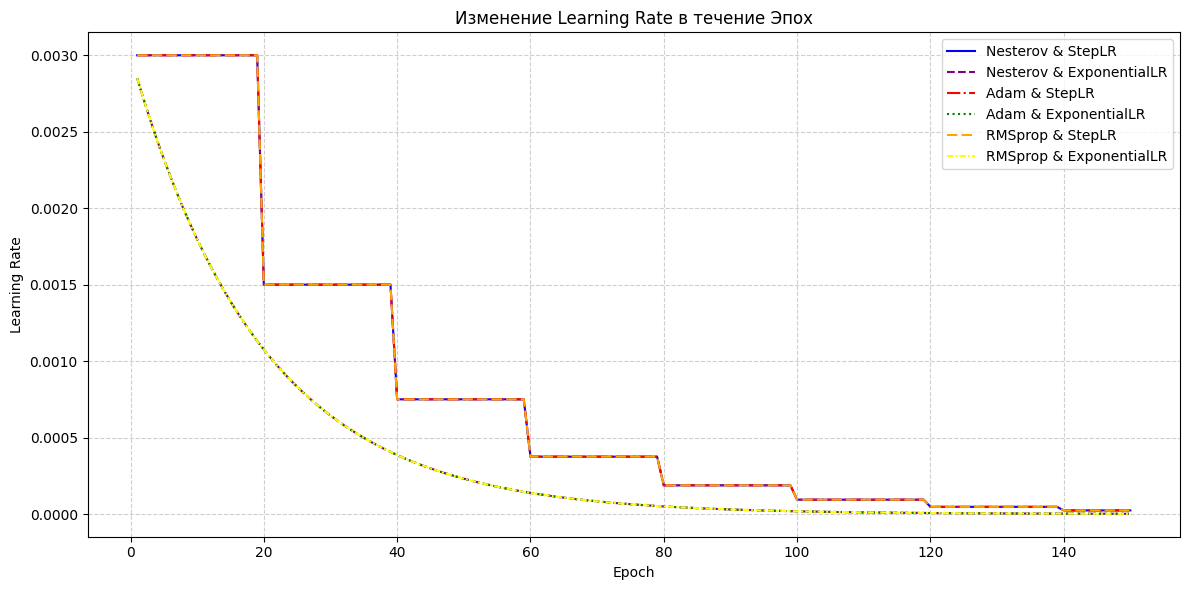

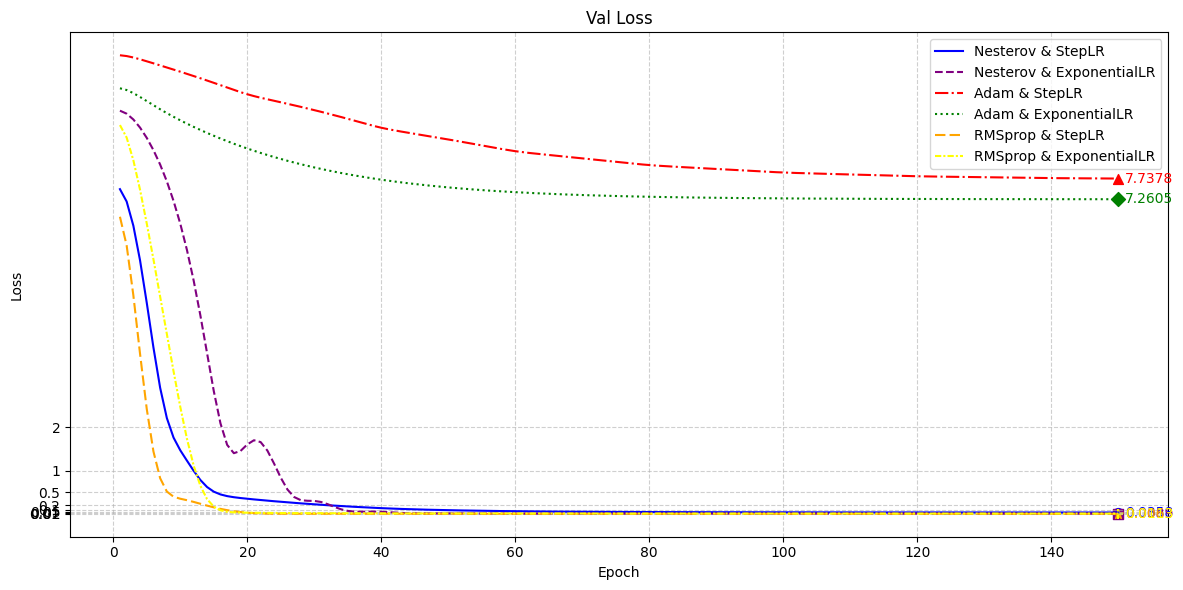

In [44]:
plt.figure(figsize=(12, 6))
for label, (color, line_style, _) in plot_styles.items():
    plt.plot(range(1, num_epochs + 1), lr_history[label], label=label, color=color, linestyle=line_style)
plt.title("Изменение Learning Rate в течение Эпох")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for label, (color, line_style, marker) in plot_styles.items():
    losses = val_loss_history[label]
    plt.plot(range(1, num_epochs + 1), losses, label=label, color=color, linestyle=line_style)
    plt.scatter(num_epochs, losses[-1], color=color, marker=marker, s=50)
    plt.text(num_epochs + 1, losses[-1], f'{losses[-1]:.4f}', fontsize=10, va='center', color=color)
plt.title("Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
# plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
ax = plt.gca()
y_ticks = [1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1, 1e0, 2e0]
ax.set_yticks(y_ticks)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}'))
plt.legend()
plt.tight_layout()
plt.show()

# Comparison with pytorch

=== ORIGINAL TABLE TESTS ===
===== TESTING OPTIMIZERS =====
Testing NesterovOptimizer...
NesterovOptimizer parameters close enough to PyTorch: True

Testing AdamOptimizer...
AdamOptimizer parameters close enough to PyTorch: True

Testing RMSpropOptimizer...
RMSpropOptimizer parameters close enough to PyTorch: True

===== TESTING SCHEDULERS =====
Testing StepLRScheduler...
StepLRScheduler matches PyTorch implementation: True

Testing ExponentialLRScheduler...
ExponentialLRScheduler matches PyTorch implementation: True

===== TEST RESULTS SUMMARY =====
Optimizers:
  Nesterov: ✓
  Adam: ✓
  RMSprop: ✓

Schedulers:
  StepLR: ✓
  ExponentialLR: ✓


=== VISUALIZATION TESTS ===
===== VISUALIZING OPTIMIZERS =====
Visualizing NesterovOptimizer vs PyTorch...


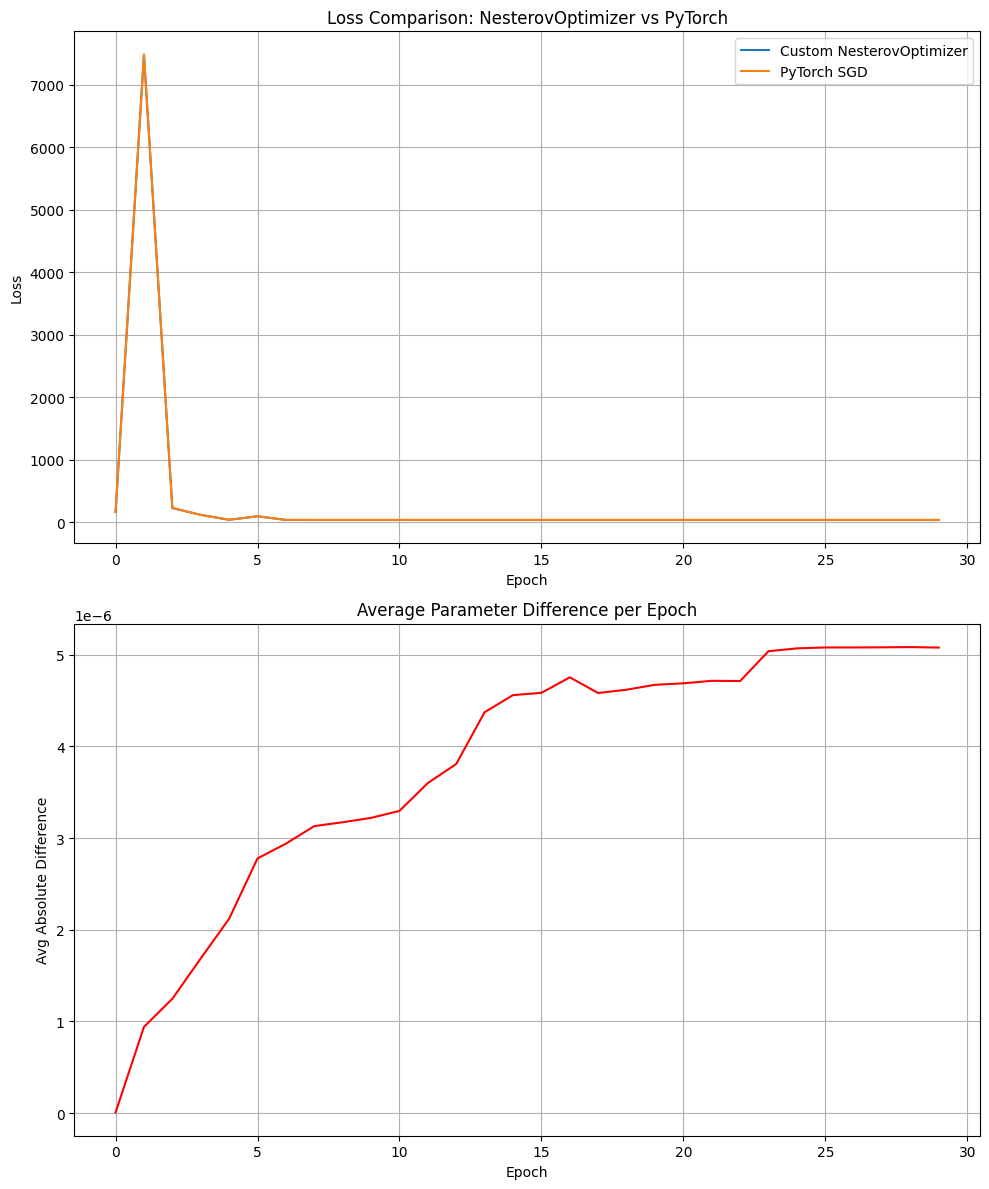

Generated visualization for Nesterov

Visualizing AdamOptimizer vs PyTorch...


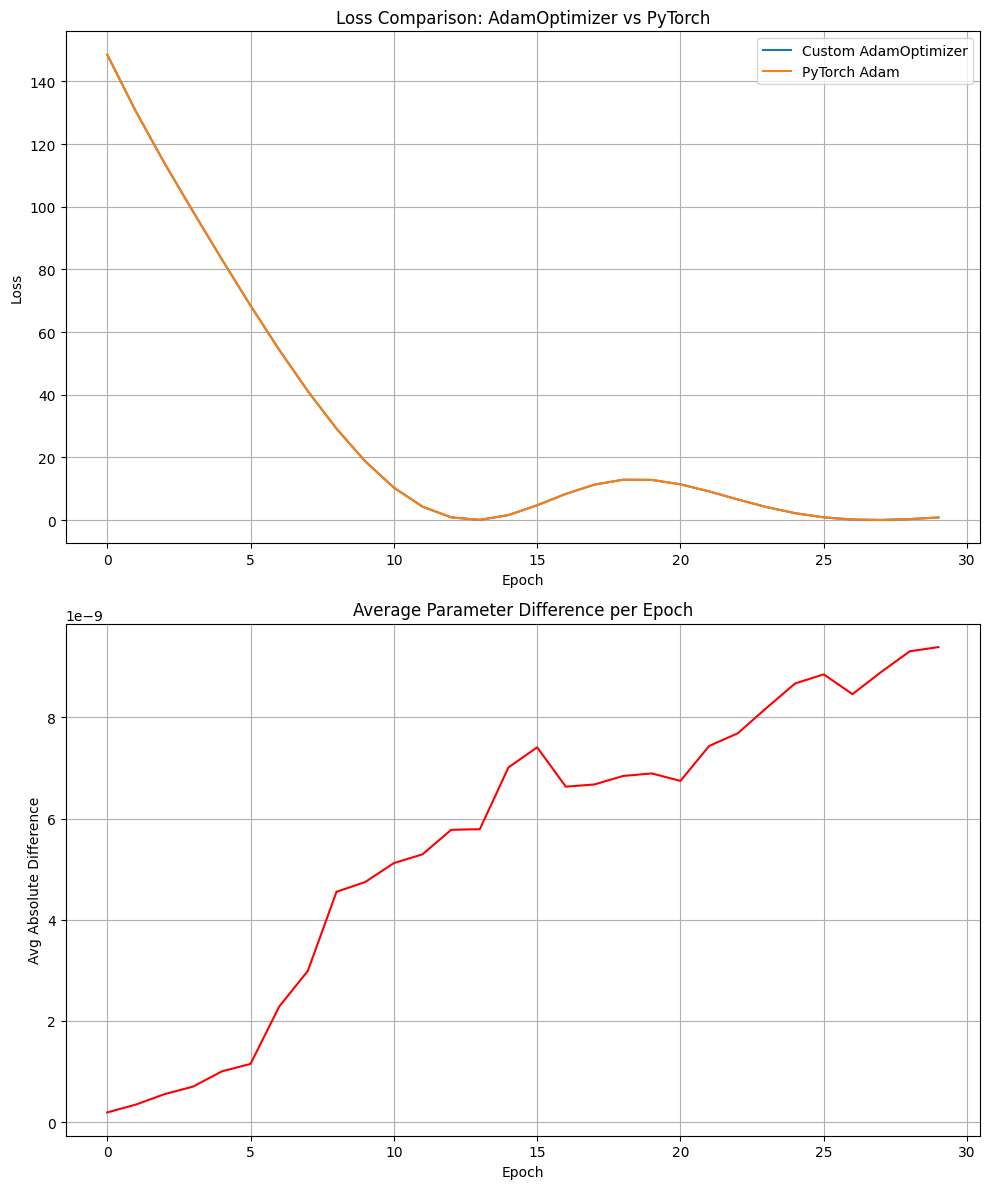

Generated visualization for Adam

Visualizing RMSpropOptimizer vs PyTorch...


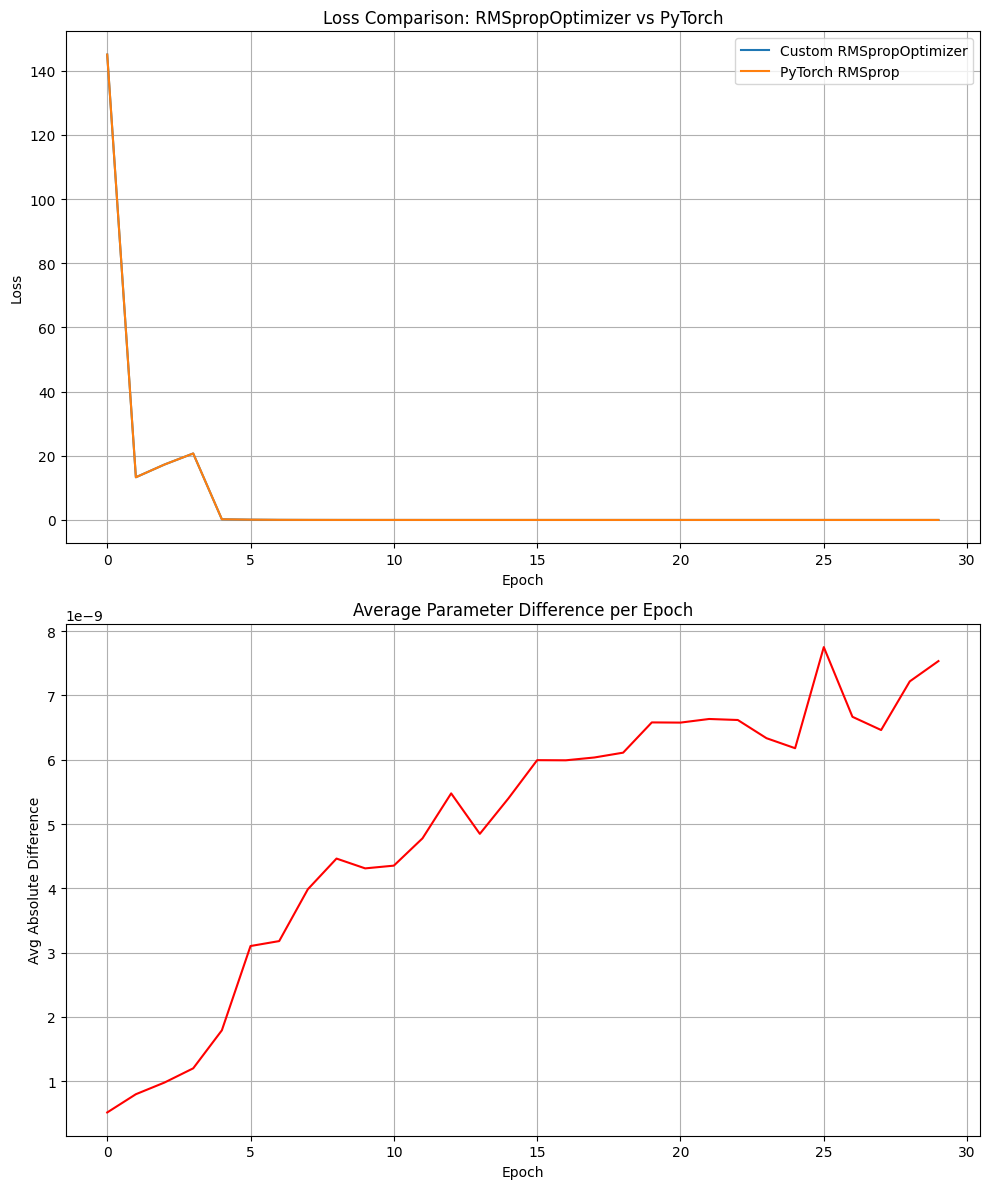

Generated visualization for RMSprop

===== VISUALIZING SCHEDULERS =====
Visualizing StepLRScheduler vs PyTorch...


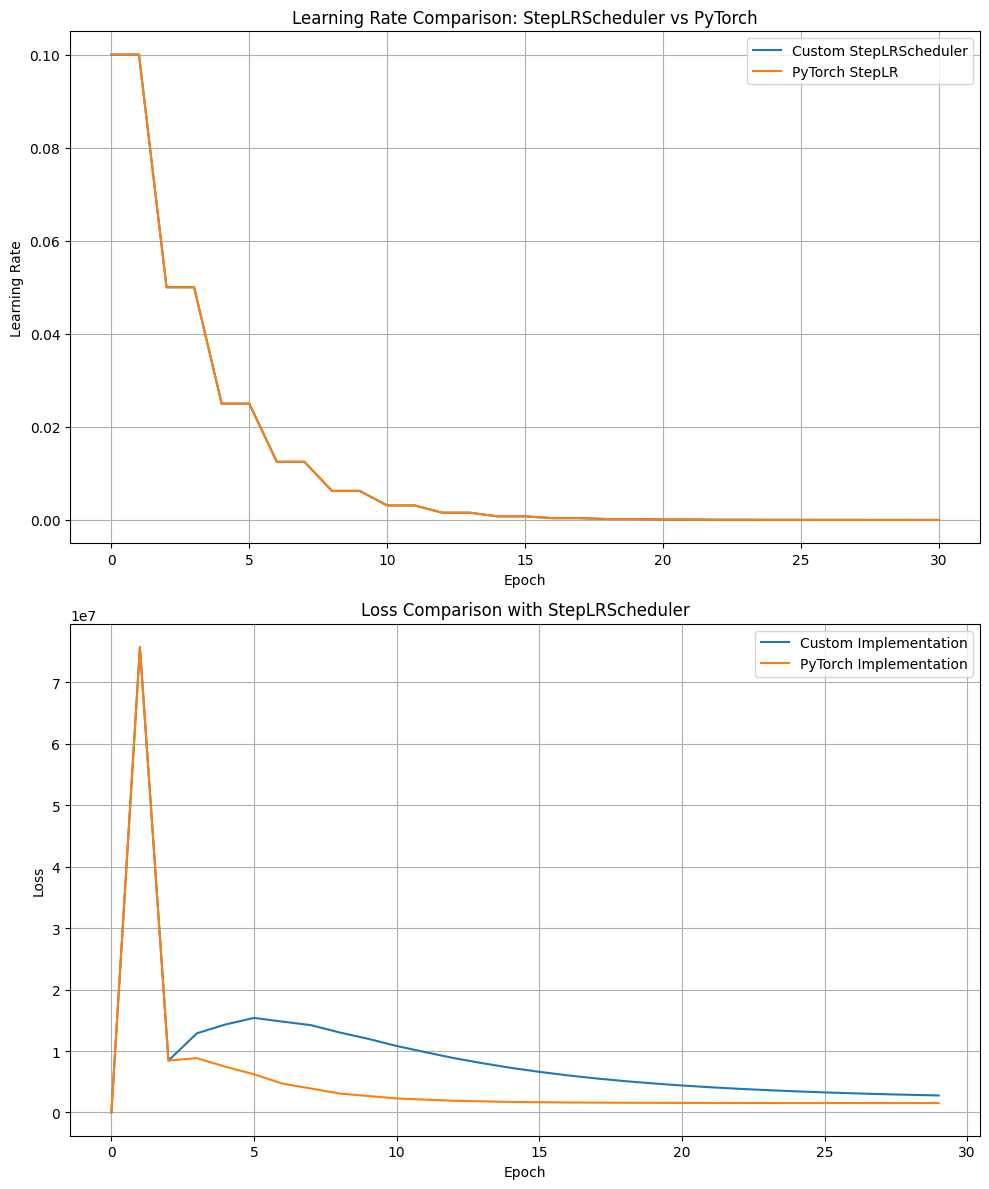

Generated visualization for StepLR

Visualizing ExponentialLRScheduler vs PyTorch...


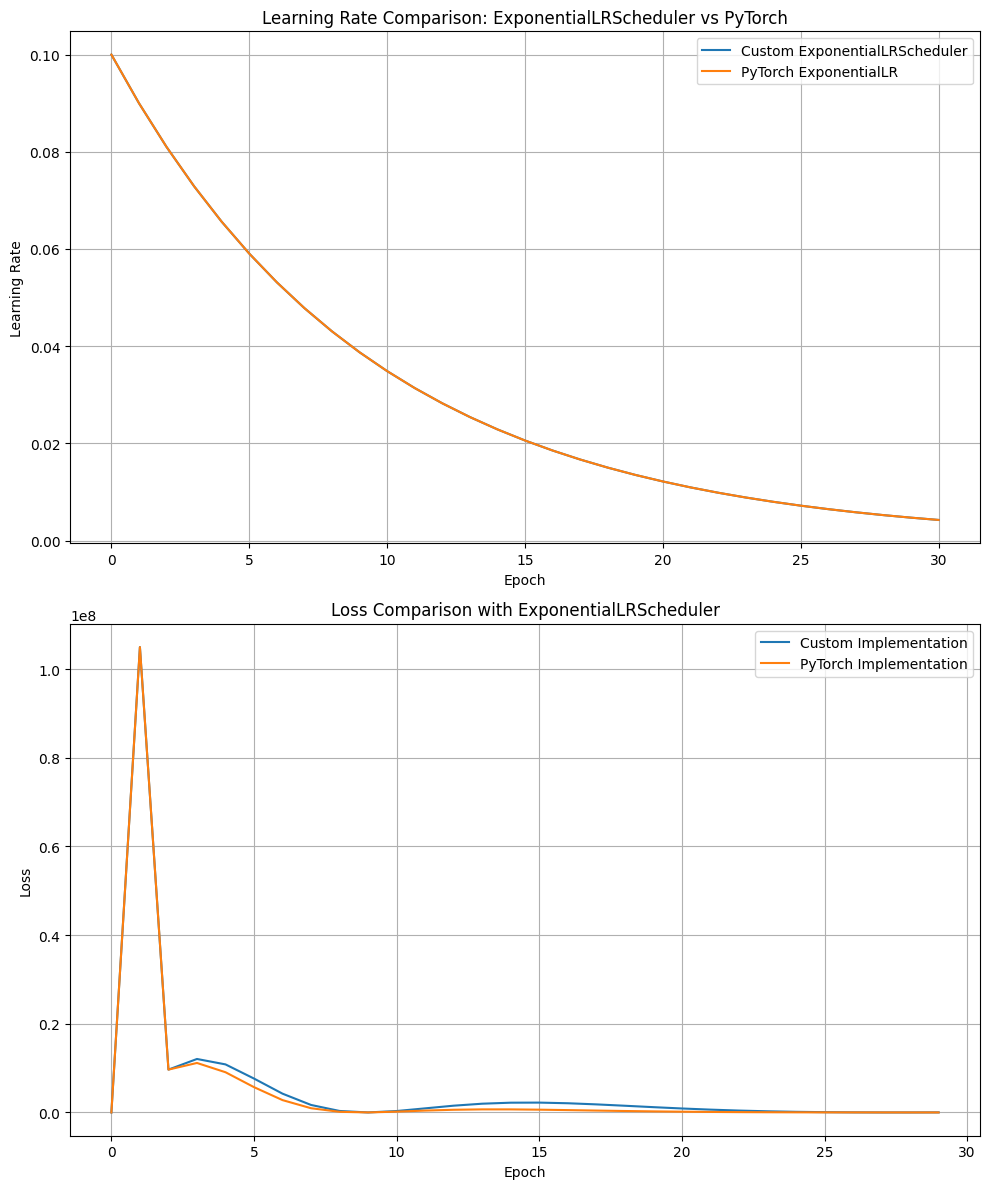

Generated visualization for ExponentialLR



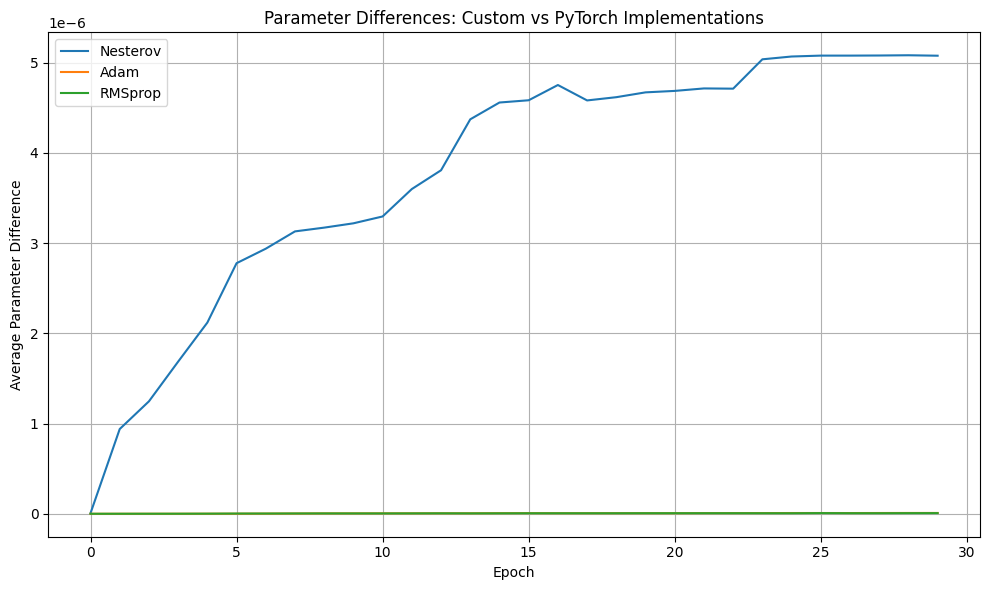

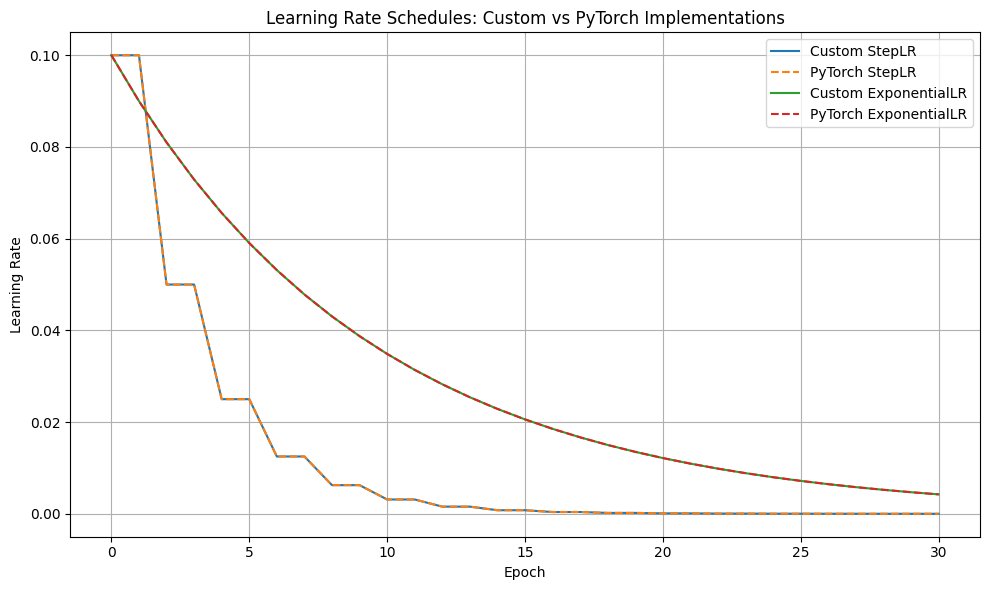


===== VISUALIZATION COMPLETE =====
Generated individual plots for each optimizer and scheduler
Generated summary plots for parameter differences and learning rates


In [45]:
def create_identical_models():
    torch.manual_seed(42)
    model1 = SimpleRegressionNN()
    model2 = deepcopy(model1)

    for p1, p2 in zip(model1.parameters(), model2.parameters()):
        assert torch.all(p1 == p2), "Models should have identical initial parameters"

    return model1, model2

def test_optimizer(custom_optimizer_class, torch_optimizer_class, optimizer_params, custom_params_mapper=None):
    print(f"Testing {custom_optimizer_class.__name__}...")
    model_custom, model_torch = create_identical_models()

    X, Y = generate_regression_data(100)
    x_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(Y, dtype=torch.float32)
    loss_fn = nn.MSELoss()

    torch_params = optimizer_params
    if custom_params_mapper:
        torch_params = custom_params_mapper(optimizer_params)

    custom_optimizer = custom_optimizer_class(model_custom.parameters(), **optimizer_params)
    torch_optimizer = torch_optimizer_class(model_torch.parameters(), **torch_params)

    for _ in range(5):
        custom_pred = model_custom(x_tensor)
        custom_loss = loss_fn(custom_pred, y_tensor)
        custom_optimizer.zero_grad()
        custom_loss.backward()
        custom_optimizer.step()

        torch_pred = model_torch(x_tensor)
        torch_loss = loss_fn(torch_pred, y_tensor)
        torch_optimizer.zero_grad()
        torch_loss.backward()
        torch_optimizer.step()

    all_close = True
    for p_custom, p_torch in zip(model_custom.parameters(), model_torch.parameters()):
        if not torch.allclose(p_custom, p_torch, rtol=1e-2, atol=1e-2):
            all_close = False
            break

    print(f"{custom_optimizer_class.__name__} parameters close enough to PyTorch: {all_close}")
    return all_close

def test_scheduler(custom_scheduler_class, torch_scheduler_class, scheduler_params, custom_params_mapper=None):
    print(f"Testing {custom_scheduler_class.__name__}...")
    model_custom, model_torch = create_identical_models()

    custom_optimizer = NesterovOptimizer(model_custom.parameters(), learning_rate=0.1)
    torch_optimizer = torch.optim.SGD(model_torch.parameters(), lr=0.1)

    torch_params = scheduler_params
    if custom_params_mapper:
        torch_params = custom_params_mapper(scheduler_params)

    custom_scheduler = custom_scheduler_class(custom_optimizer, **scheduler_params)
    torch_scheduler = torch_scheduler_class(torch_optimizer, **torch_params)

    initial_lr = custom_optimizer.learning_rate
    assert initial_lr == torch_optimizer.param_groups[0]['lr'], "Initial learning rates should be equal"

    learning_rates_custom = [initial_lr]
    learning_rates_torch = [initial_lr]

    for _ in range(5):
        custom_scheduler.step()
        torch_scheduler.step()

        learning_rates_custom.append(custom_optimizer.learning_rate)
        learning_rates_torch.append(torch_optimizer.param_groups[0]['lr'])

    all_close = True
    for i, (lr_custom, lr_torch) in enumerate(zip(learning_rates_custom, learning_rates_torch)):
        if abs(lr_custom - lr_torch) >= 1e-6:
            print(f"Learning rates differ at step {i}: {lr_custom} vs {lr_torch}")
            all_close = False
            break

    print(f"{custom_scheduler_class.__name__} matches PyTorch implementation: {all_close}")
    return all_close

def visualize_optimizer_comparison(custom_optimizer_class, torch_optimizer_class, optimizer_params,
                                  custom_params_mapper=None, epochs=20):
    print(f"Visualizing {custom_optimizer_class.__name__} vs PyTorch...")
    model_custom, model_torch = create_identical_models()

    X, Y = generate_regression_data(100)
    x_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(Y, dtype=torch.float32)
    loss_fn = nn.MSELoss()

    torch_params = optimizer_params
    if custom_params_mapper:
        torch_params = custom_params_mapper(optimizer_params)

    custom_optimizer = custom_optimizer_class(model_custom.parameters(), **optimizer_params)
    torch_optimizer = torch_optimizer_class(model_torch.parameters(), **torch_params)

    # For storing results
    custom_losses = []
    torch_losses = []
    param_diffs = []

    for epoch in range(epochs):
        # Custom optimizer step
        custom_pred = model_custom(x_tensor)
        custom_loss = loss_fn(custom_pred, y_tensor)
        custom_optimizer.zero_grad()
        custom_loss.backward()
        custom_optimizer.step()
        custom_losses.append(custom_loss.item())

        # PyTorch optimizer step
        torch_pred = model_torch(x_tensor)
        torch_loss = loss_fn(torch_pred, y_tensor)
        torch_optimizer.zero_grad()
        torch_loss.backward()
        torch_optimizer.step()
        torch_losses.append(torch_loss.item())

        # Calculate parameter differences
        total_diff = 0
        param_count = 0
        for p_custom, p_torch in zip(model_custom.parameters(), model_torch.parameters()):
            diff = torch.abs(p_custom - p_torch).mean().item()
            total_diff += diff
            param_count += 1

        avg_diff = total_diff / param_count if param_count > 0 else 0
        param_diffs.append(avg_diff)

    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

    # Plot loss comparison
    ax1.plot(custom_losses, label=f'Custom {custom_optimizer_class.__name__}')
    ax1.plot(torch_losses, label=f'PyTorch {torch_optimizer_class.__name__}')
    ax1.set_title(f'Loss Comparison: {custom_optimizer_class.__name__} vs PyTorch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot parameter differences
    ax2.plot(param_diffs, color='red')
    ax2.set_title(f'Average Parameter Difference per Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Avg Absolute Difference')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'{custom_optimizer_class.__name__}_comparison.png')

    # Display the plot
    plt.show()

    return custom_losses, torch_losses, param_diffs

def visualize_scheduler_comparison(custom_scheduler_class, torch_scheduler_class, scheduler_params,
                                  custom_params_mapper=None, epochs=20):
    print(f"Visualizing {custom_scheduler_class.__name__} vs PyTorch...")
    model_custom, model_torch = create_identical_models()

    X, Y = generate_regression_data(100)
    x_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(Y, dtype=torch.float32)
    loss_fn = nn.MSELoss()

    # Use same optimizer type for both to isolate scheduler differences
    initial_lr = 0.1
    custom_optimizer = NesterovOptimizer(model_custom.parameters(), learning_rate=initial_lr)
    torch_optimizer = torch.optim.SGD(model_torch.parameters(), lr=initial_lr, momentum=0.9, nesterov=True)

    torch_params = scheduler_params
    if custom_params_mapper:
        torch_params = custom_params_mapper(scheduler_params)

    custom_scheduler = custom_scheduler_class(custom_optimizer, **scheduler_params)
    torch_scheduler = torch_scheduler_class(torch_optimizer, **torch_params)

    # For storing results
    custom_lrs = [custom_optimizer.learning_rate]
    torch_lrs = [torch_optimizer.param_groups[0]['lr']]
    custom_losses = []
    torch_losses = []

    for epoch in range(epochs):
        # Custom training step
        custom_pred = model_custom(x_tensor)
        custom_loss = loss_fn(custom_pred, y_tensor)
        custom_optimizer.zero_grad()
        custom_loss.backward()
        custom_optimizer.step()
        custom_losses.append(custom_loss.item())

        # PyTorch training step
        torch_pred = model_torch(x_tensor)
        torch_loss = loss_fn(torch_pred, y_tensor)
        torch_optimizer.zero_grad()
        torch_loss.backward()
        torch_optimizer.step()
        torch_losses.append(torch_loss.item())

        # Update schedulers
        custom_scheduler.step()
        torch_scheduler.step()

        # Record learning rates
        custom_lrs.append(custom_optimizer.learning_rate)
        torch_lrs.append(torch_optimizer.param_groups[0]['lr'])

    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

    # Plot learning rate comparison
    ax1.plot(custom_lrs, label=f'Custom {custom_scheduler_class.__name__}')
    ax1.plot(torch_lrs, label=f'PyTorch {torch_scheduler_class.__name__}')
    ax1.set_title(f'Learning Rate Comparison: {custom_scheduler_class.__name__} vs PyTorch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Learning Rate')
    ax1.legend()
    ax1.grid(True)

    # Plot loss comparison
    ax2.plot(custom_losses, label=f'Custom Implementation')
    ax2.plot(torch_losses, label=f'PyTorch Implementation')
    ax2.set_title(f'Loss Comparison with {custom_scheduler_class.__name__}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'{custom_scheduler_class.__name__}_comparison.png')

    # Display the plot
    plt.show()

    return custom_lrs, torch_lrs, custom_losses, torch_losses

def map_nesterov_params(params):
    return {
        'lr': params['learning_rate'],
        'momentum': params['momentum_factor'],
        'nesterov': True
    }

def map_adam_params(params):
    return {
        'lr': params['learning_rate'],
        'betas': (params['beta1'], params['beta2']),
        'eps': params['epsilon']
    }

def map_rmsprop_params(params):
    return {
        'lr': params['learning_rate'],
        'alpha': params['decay_rate'],
        'eps': params['epsilon']
    }

def map_step_lr_params(params):
    return {
        'step_size': params['step_size'],
        'gamma': params['gamma_factor']
    }

def map_exp_lr_params(params):
    return {
        'gamma': params['gamma_factor']
    }

def run_all_tests(epochs=30):
    """Run both original tests and visualization tests"""

    optimizer_tests = [
        {
            'name': 'Nesterov',
            'custom_class': NesterovOptimizer,
            'torch_class': torch.optim.SGD,
            'params': {'learning_rate': 0.01, 'momentum_factor': 0.9},
            'params_mapper': map_nesterov_params
        },
        {
            'name': 'Adam',
            'custom_class': AdamOptimizer,
            'torch_class': torch.optim.Adam,
            'params': {'learning_rate': 0.01, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8},
            'params_mapper': map_adam_params
        },
        {
            'name': 'RMSprop',
            'custom_class': RMSpropOptimizer,
            'torch_class': torch.optim.RMSprop,
            'params': {'learning_rate': 0.01, 'decay_rate': 0.99, 'epsilon': 1e-4},
            'params_mapper': map_rmsprop_params
        }
    ]

    scheduler_tests = [
        {
            'name': 'StepLR',
            'custom_class': StepLRScheduler,
            'torch_class': torch.optim.lr_scheduler.StepLR,
            'params': {'step_size': 2, 'gamma_factor': 0.5},
            'params_mapper': map_step_lr_params
        },
        {
            'name': 'ExponentialLR',
            'custom_class': ExponentialLRScheduler,
            'torch_class': torch.optim.lr_scheduler.ExponentialLR,
            'params': {'gamma_factor': 0.9},
            'params_mapper': map_exp_lr_params
        }
    ]

    # Run original table tests first
    print("=== ORIGINAL TABLE TESTS ===")
    print("===== TESTING OPTIMIZERS =====")
    optimizer_results = {}
    for test in optimizer_tests:
        result = test_optimizer(
            test['custom_class'],
            test['torch_class'],
            test['params'],
            test['params_mapper']
        )
        optimizer_results[test['name']] = result
        print()

    print("===== TESTING SCHEDULERS =====")
    scheduler_results = {}
    for test in scheduler_tests:
        result = test_scheduler(
            test['custom_class'],
            test['torch_class'],
            test['params'],
            test['params_mapper']
        )
        scheduler_results[test['name']] = result
        print()

    print("===== TEST RESULTS SUMMARY =====")
    print("Optimizers:")
    for name, result in optimizer_results.items():
        print(f"  {name}: {'✓' if result else '✗'}")

    print("\nSchedulers:")
    for name, result in scheduler_results.items():
        print(f"  {name}: {'✓' if result else '✗'}")

    # Now run visualization tests
    print("\n\n=== VISUALIZATION TESTS ===")
    print("===== VISUALIZING OPTIMIZERS =====")
    optimizer_viz_results = {}
    for test in optimizer_tests:
        results = visualize_optimizer_comparison(
            test['custom_class'],
            test['torch_class'],
            test['params'],
            test['params_mapper'],
            epochs=epochs
        )
        optimizer_viz_results[test['name']] = results
        print(f"Generated visualization for {test['name']}")
        print()

    print("===== VISUALIZING SCHEDULERS =====")
    scheduler_viz_results = {}
    for test in scheduler_tests:
        results = visualize_scheduler_comparison(
            test['custom_class'],
            test['torch_class'],
            test['params'],
            test['params_mapper'],
            epochs=epochs
        )
        scheduler_viz_results[test['name']] = results
        print(f"Generated visualization for {test['name']}")
        print()

    # Create a summary visualization of parameter differences for all optimizers
    plt.figure(figsize=(10, 6))
    for test in optimizer_tests:
        name = test['name']
        _, _, param_diffs = optimizer_viz_results[name]
        plt.plot(param_diffs, label=name)

    plt.title('Parameter Differences: Custom vs PyTorch Implementations')
    plt.xlabel('Epoch')
    plt.ylabel('Average Parameter Difference')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('optimizer_param_differences_summary.png')
    plt.show()

    # Create a summary visualization of learning rate changes for all schedulers
    plt.figure(figsize=(10, 6))
    for test in scheduler_tests:
        name = test['name']
        custom_lrs, torch_lrs, _, _ = scheduler_viz_results[name]
        plt.plot(custom_lrs, label=f'Custom {name}', linestyle='-')
        plt.plot(torch_lrs, label=f'PyTorch {name}', linestyle='--')

    plt.title('Learning Rate Schedules: Custom vs PyTorch Implementations')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('scheduler_learning_rates_summary.png')
    plt.show()

    print("\n===== VISUALIZATION COMPLETE =====")
    print("Generated individual plots for each optimizer and scheduler")
    print("Generated summary plots for parameter differences and learning rates")

if __name__ == "__main__":
    # Uncomment the appropriate function call based on what you want to run
    # run_table_tests()  # Original test function from your code
    run_all_tests(epochs=30)  # Run both original tests and visualization tests